# 01 — Data Extraction & EDA
**Spotify Analytics · spotify_analytics DB**

Goals:
1. Connect to MySQL and extract all relevant tables
2. Assess data quality and reccobeats API coverage (`dim_audio_features`)
3. Explore distributions of all key features
4. Understand playlist composition and cross-playlist overlap
5. Surface insights that may inform new modeling ideas

## 0. Setup

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text
import warnings
warnings.filterwarnings('ignore')

# ── Plot defaults ──────────────────────────────────────────────────
sns.set_theme(style='darkgrid', palette='husl')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

In [14]:
from dotenv import load_dotenv
import os

load_dotenv()  # looks for .env in the current directory

DB_USER     = os.getenv('DB_USER')
DB_PASSWORD = os.getenv('DB_PASSWORD')
DB_HOST     = os.getenv('DB_HOST')
DB_PORT     = int(os.getenv('DB_PORT', 3306))
DB_NAME     = os.getenv('DB_NAME', 'spotify_analytics')

engine = create_engine(
    f'mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}',
    connect_args={'connect_timeout': 10}
)

# Quick connectivity test
with engine.connect() as conn:
    result = conn.execute(text('SELECT VERSION()')).fetchone()
    print(f'Connected ✓  MySQL {result[0]}')

Connected ✓  MySQL 8.0.42


## 1. Raw Extraction

In [15]:
# ── Main analytical query: one row per fact record ─────────────────
QUERY = """
SELECT
    -- Identifiers
    fs.id                        AS fact_id,
    s.spotify_id                 AS track_id,
    s.name                       AS track_name,
    s.is_local,
    s.has_audio_features,

    -- Playlist
    pl.name                      AS playlist_name,
    pl.is_personal,
    pl.followers                 AS playlist_followers,

    -- Artist (primary only)
    ar.name                      AS artist_name,
    ar.popularity                AS artist_popularity,
    ar.genres                    AS artist_genres,

    -- Album
    al.name                      AS album_name,
    al.release_date,

    -- Date dimensions
    rd.year                      AS release_year,
    rd.decade,
    da.full_date                 AS date_added,
    da.year                      AS year_added,
    da.month                     AS month_added,
    da.day_name                  AS day_added,
    da.season                    AS season_added,
    da.is_weekend                AS added_on_weekend,

    -- Raw measures
    fs.popularity_raw,
    fs.duration_raw,
    fs.added_by,

    -- Dimension labels
    pop.range_name               AS popularity_label,
    dur.range_name               AS duration_label,
    
    -- Audio features (reccobeats enrichment)
    af.danceability,
    af.energy,
    af.valence,
    af.tempo,
    af.loudness,
    af.acousticness,
    af.instrumentalness,
    af.liveness,
    af.speechiness,
    af.key_value,
    af.mode,
    af.time_signature,
    af.explicit,
    af.track_number,

    -- Mood quadrant (from view logic)
    CASE
        WHEN af.energy >= 0.5 AND af.valence >= 0.5 THEN 'Happy/Energetic'
        WHEN af.energy >= 0.5 AND af.valence <  0.5 THEN 'Angry/Tense'
        WHEN af.energy <  0.5 AND af.valence >= 0.5 THEN 'Peaceful/Calm'
        WHEN af.energy <  0.5 AND af.valence <  0.5 THEN 'Sad/Depressing'
        ELSE NULL
    END                          AS mood_quadrant

FROM fac_songs fs
JOIN dim_songs      s   ON fs.dim_song_id           = s.id
JOIN dim_playlist   pl  ON fs.dim_playlist_id       = pl.id
JOIN dim_album      al  ON fs.dim_album_id          = al.id
JOIN bridge_song_artists bsa ON fs.dim_song_id      = bsa.dim_song_id
JOIN dim_artist     ar  ON bsa.dim_artist_id        = ar.id
LEFT JOIN dim_releasedate  rd  ON fs.dim_releasedate_id  = rd.id
LEFT JOIN dim_date         da  ON fs.dim_date_added_id   = da.id
LEFT JOIN dim_popularity   pop ON fs.dim_popularity_id   = pop.id
LEFT JOIN dim_duration     dur ON fs.dim_duration_id     = dur.id
LEFT JOIN dim_audio_features af ON fs.dim_audio_features_id = af.id
WHERE bsa.is_primary = TRUE
"""

df = pd.read_sql(QUERY, engine)
print(f'Rows: {len(df):,}  |  Columns: {df.shape[1]}')
df.head(3)

Rows: 2,998  |  Columns: 41


,fact_id,track_id,track_name,is_local,has_audio_features,playlist_name,is_personal,playlist_followers,artist_name,artist_popularity,artist_genres,album_name,release_date,release_year,decade,date_added,year_added,month_added,day_added,season_added,added_on_weekend,popularity_raw,duration_raw,added_by,popularity_label,duration_label,danceability,energy,valence,tempo,loudness,acousticness,instrumentalness,liveness,speechiness,key_value,mode,time_signature,explicit,track_number,mood_quadrant
0,1,6GPkBUXMrGSkwK3TrrHHXN,Muchacha (Ojos de Papel),0,0,AQ7,1,1,Almendra,46,"argentine rock, latin rock",Almendra (50 Años),1970-01-01,1970,1970,2020-12-19,2020,12,Saturday,Winter,1,55,3.0700,facurabinovich7,Moderate,Medium,0.3650,0.2850,0.5520,171.3950,-9.9540,0.9810,0.0012,0.1200,0.0378,7.0000,1.0000,None,0.0000,None,Peaceful/Calm
1,2,2P2tl8JT698TJJ55ScKyku,Ana No Duerme,0,0,AQ7,1,1,Almendra,46,"argentine rock, latin rock",Almendra (50 Años),1970-01-01,1970,1970,2020-12-19,2020,12,Saturday,Winter,1,43,2.7000,facurabinovich7,Moderate,Short,0.3560,0.5040,0.6880,79.1640,-8.9980,0.6510,0.0000,0.2380,0.0319,1.0000,0.0000,None,0.0000,None,Happy/Energetic
2,3,7H62s62eUQqYXTA3WsrTK7,Necesito,0,0,AQ7,1,1,Sui Generis,50,"argentine rock, latin rock, trova, nueva trova...",Vida,1972-06-22,1972,1970,2020-12-19,2020,12,Saturday,Winter,1,51,2.2300,facurabinovich7,Moderate,Short,0.6400,0.1690,0.1990,101.8600,-18.1950,0.4610,0.0000,0.1240,0.0461,7.0000,1.0000,None,0.0000,None,Sad/Depressing


## 2. Data Quality & Coverage

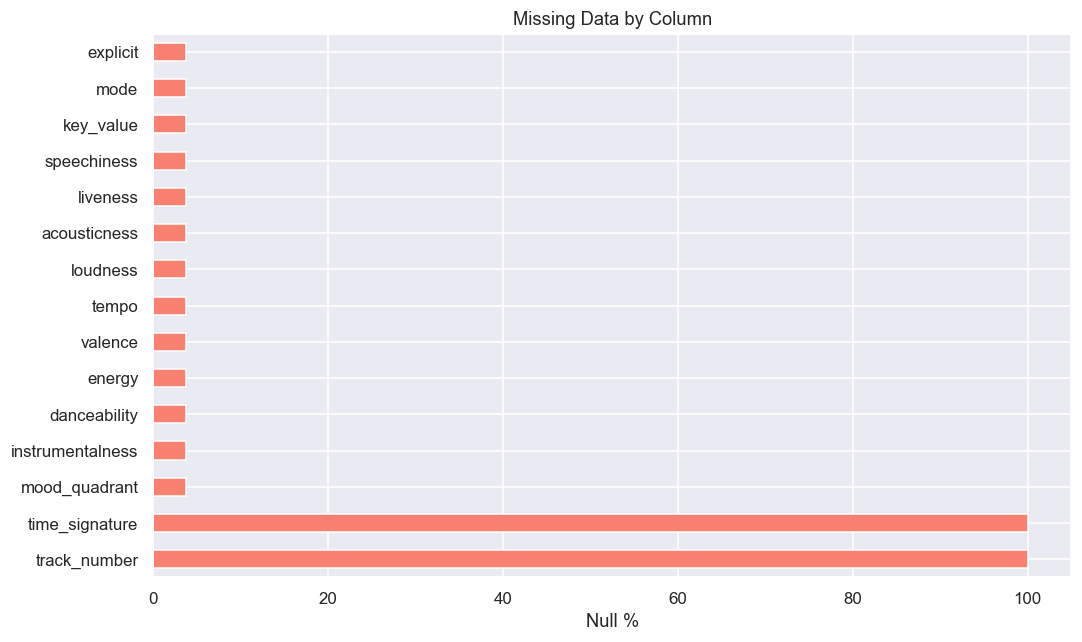

track_number       100.0000
time_signature     100.0000
mood_quadrant        3.8025
instrumentalness     3.8025
danceability         3.8025
energy               3.8025
valence              3.8025
tempo                3.8025
loudness             3.8025
acousticness         3.8025
liveness             3.8025
speechiness          3.8025
key_value            3.8025
mode                 3.8025
explicit             3.8025


In [16]:
# ── Overall null rates ─────────────────────────────────────────────
null_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
null_pct = null_pct[null_pct > 0]

fig, ax = plt.subplots(figsize=(10, max(4, len(null_pct) * 0.4)))
null_pct.plot(kind='barh', ax=ax, color='salmon')
ax.set_xlabel('Null %')
ax.set_title('Missing Data by Column')
plt.tight_layout()
plt.show()

print(null_pct.to_string())

Total fact rows      : 2,998
With audio features  : 2,884  (96.2%)
Without audio features: 114  (3.8%)
Local tracks (no API): 0


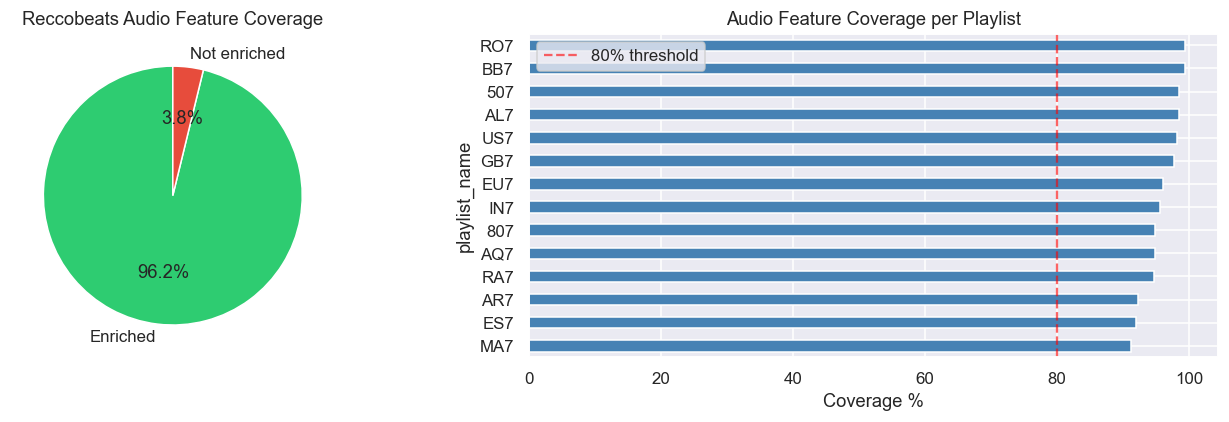

In [17]:
# ── Reccobeats coverage: how many tracks have audio features? ──────
total       = len(df)
enriched    = df['danceability'].notna().sum()
not_enriched = total - enriched
local_tracks = df['is_local'].sum()

print(f'Total fact rows      : {total:,}')
print(f'With audio features  : {enriched:,}  ({enriched/total*100:.1f}%)')
print(f'Without audio features: {not_enriched:,}  ({not_enriched/total*100:.1f}%)')
print(f'Local tracks (no API): {local_tracks:,}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Coverage pie
axes[0].pie([enriched, not_enriched], labels=['Enriched', 'Not enriched'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[0].set_title('Reccobeats Audio Feature Coverage')

# Coverage per playlist
cov = df.groupby('playlist_name').apply(
    lambda x: x['danceability'].notna().sum() / len(x) * 100
).sort_values()
cov.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_xlabel('Coverage %')
axes[1].set_title('Audio Feature Coverage per Playlist')
axes[1].axvline(80, color='red', linestyle='--', alpha=0.6, label='80% threshold')
axes[1].legend()

plt.tight_layout()
plt.show()

In [18]:
# ── Tracks missing audio features: are they local or just un-enriched? ─
missing_af = df[df['danceability'].isna()]
print('Missing audio features breakdown:')
print(missing_af.groupby('playlist_name')[['track_name', 'is_local']]
      .agg(count=('track_name','count'), local=('is_local','sum'))
      .assign(non_local=lambda x: x['count'] - x['local'])
      .sort_values('count', ascending=False))

Missing audio features breakdown:
               count  local  non_local
playlist_name                         
807               22      0         22
MA7               21      0         21
IN7               19      0         19
AR7               11      0         11
GB7                8      0          8
EU7                7      0          7
RA7                6      0          6
US7                5      0          5
ES7                4      0          4
507                3      0          3
AL7                3      0          3
AQ7                3      0          3
BB7                1      0          1
RO7                1      0          1


## 3. Playlist Overview

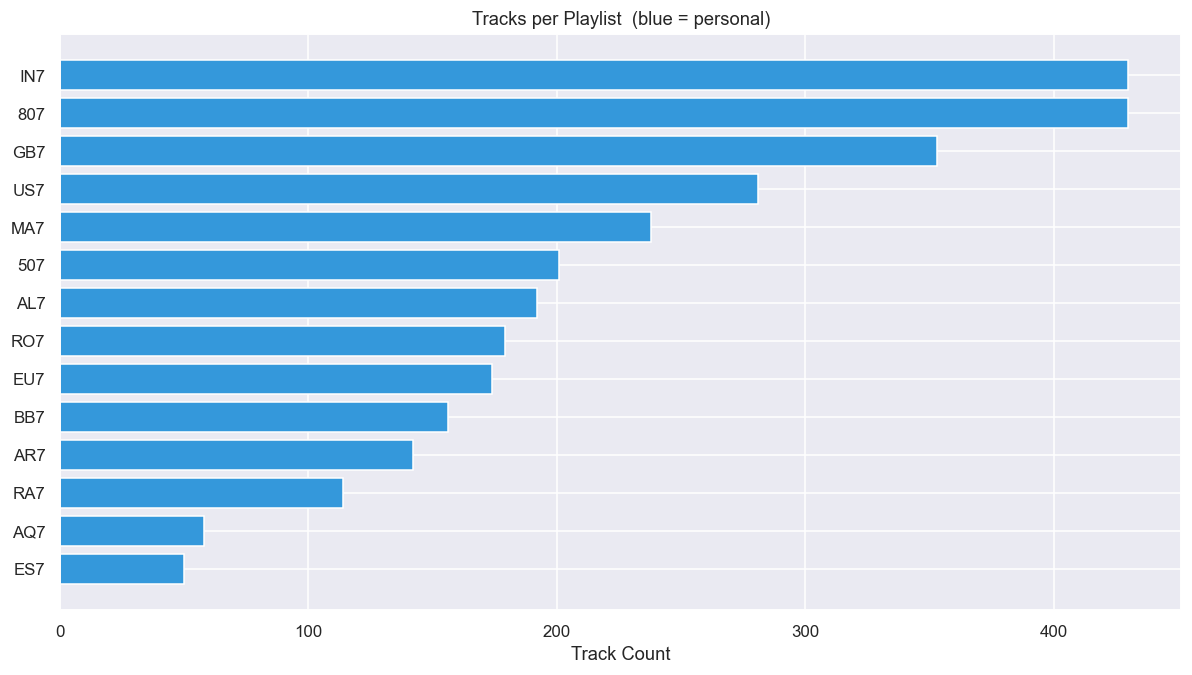

playlist  is_personal  track_count
     807            1          430
     IN7            1          430
     GB7            1          353
     US7            1          281
     MA7            1          238
     507            1          201
     AL7            1          192
     RO7            1          179
     EU7            1          174
     BB7            1          156
     AR7            1          142
     RA7            1          114
     AQ7            1           58
     ES7            1           50


In [19]:
# ── Track count per playlist ───────────────────────────────────────
pl_counts = df.groupby(['playlist_name', 'is_personal'])['fact_id'].count().reset_index()
pl_counts.columns = ['playlist', 'is_personal', 'track_count']
pl_counts = pl_counts.sort_values('track_count', ascending=True)

colors = ['#3498db' if p else '#95a5a6' for p in pl_counts['is_personal']]
fig, ax = plt.subplots(figsize=(11, max(4, len(pl_counts)*0.45)))
ax.barh(pl_counts['playlist'], pl_counts['track_count'], color=colors)
ax.set_xlabel('Track Count')
ax.set_title('Tracks per Playlist  (blue = personal)')
plt.tight_layout()
plt.show()
print(pl_counts.sort_values('track_count', ascending=False).to_string(index=False))

Unique tracks in multiple playlists: 108
Tracks appearing in exactly 1 playlist: 2,531


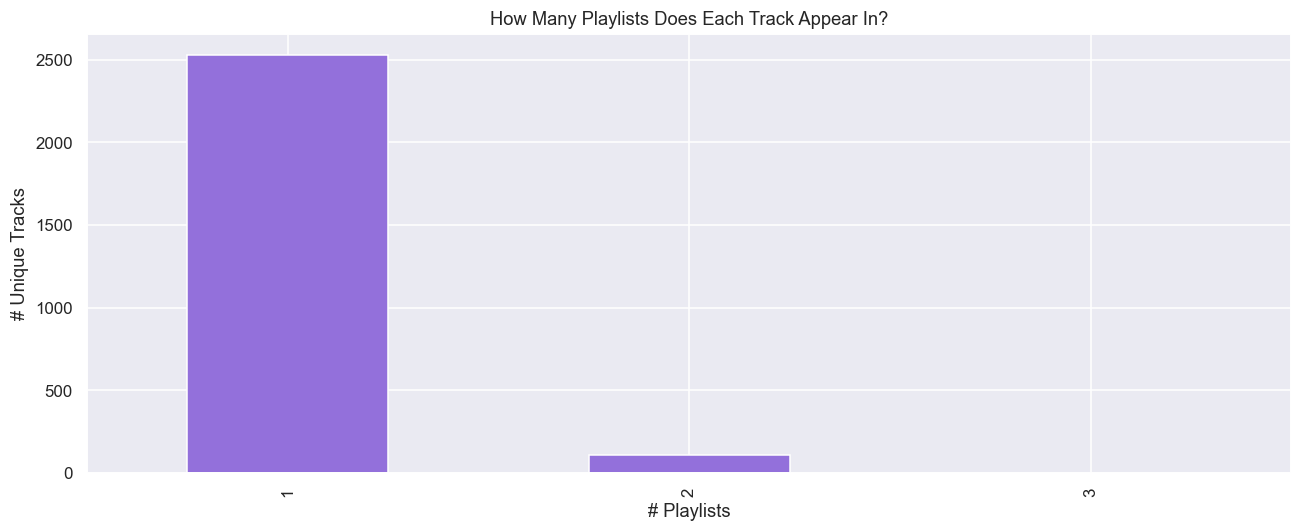

In [20]:
# ── Cross-playlist song overlap ────────────────────────────────────
# Songs appearing in more than one playlist
overlap = df.groupby('track_id')['playlist_name'].nunique()
multi   = overlap[overlap > 1]
print(f'Unique tracks in multiple playlists: {len(multi):,}')
print(f'Tracks appearing in exactly 1 playlist: {(overlap == 1).sum():,}')

overlap.value_counts().sort_index().plot(
    kind='bar', title='How Many Playlists Does Each Track Appear In?',
    xlabel='# Playlists', ylabel='# Unique Tracks', color='mediumpurple'
)
plt.tight_layout()
plt.show()

## 4. Audio Feature Distributions

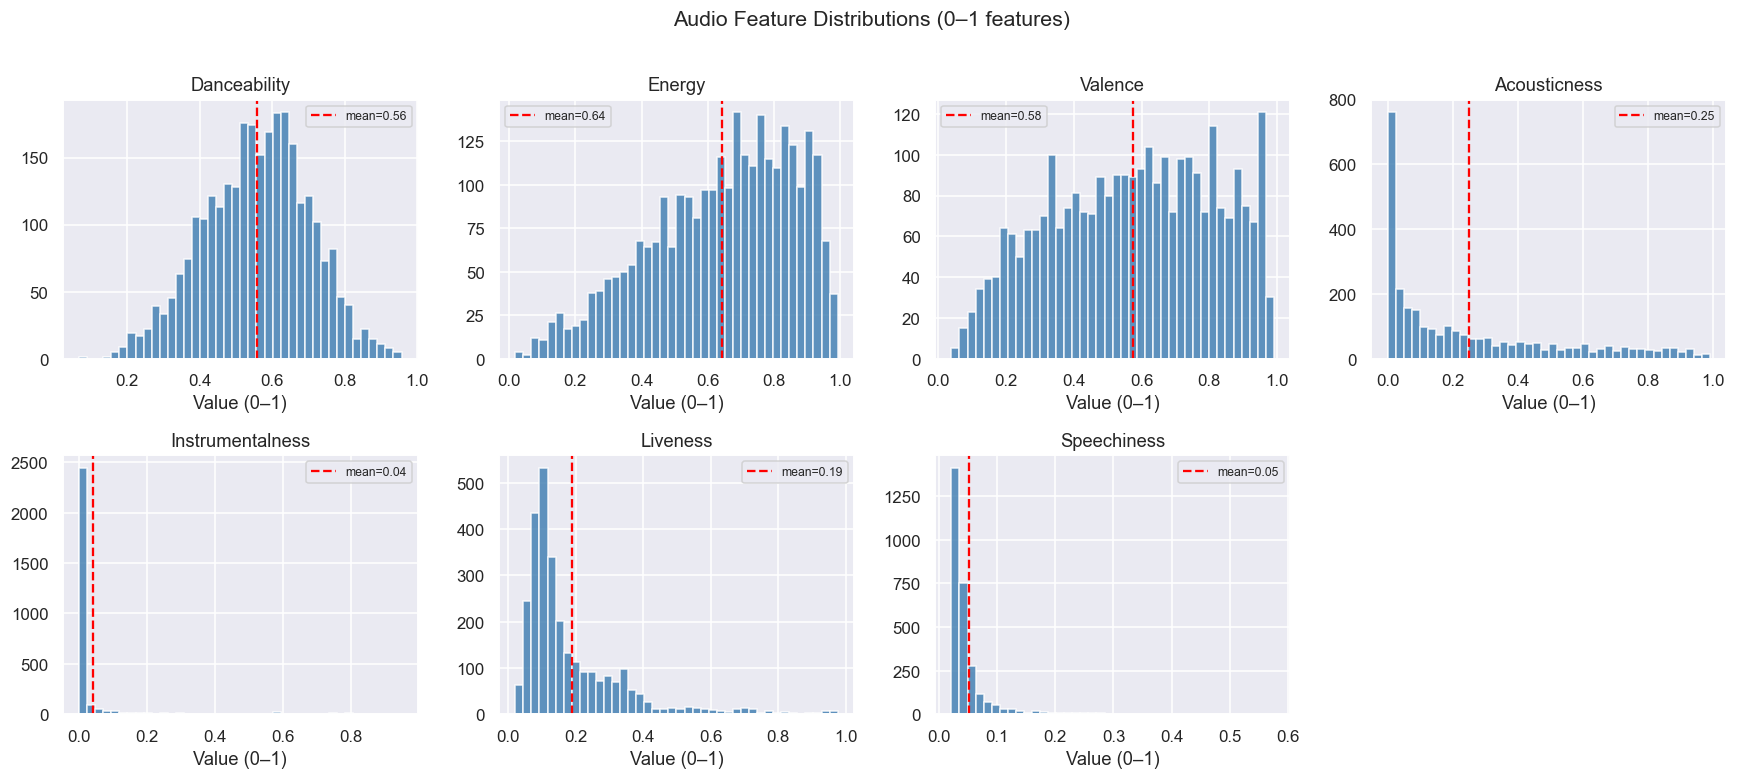

In [21]:
AUDIO_FEATURES = ['danceability', 'energy', 'valence', 'acousticness',
                  'instrumentalness', 'liveness', 'speechiness']

df_af = df[df['danceability'].notna()].copy()

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, feat in enumerate(AUDIO_FEATURES):
    axes[i].hist(df_af[feat], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(feat.capitalize())
    axes[i].set_xlabel('Value (0–1)')
    mean_val = df_af[feat].mean()
    axes[i].axvline(mean_val, color='red', linestyle='--', label=f'mean={mean_val:.2f}')
    axes[i].legend(fontsize=8)

axes[-1].axis('off')  # hide last empty subplot
fig.suptitle('Audio Feature Distributions (0–1 features)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Implication for KMeans feature set:
Keep as-is: danceability, energy, valence, acousticness, tempo, loudness.
A possibility is to: 
- Log-transform then scale -> instrumentalness, speechiness (and optionally liveness)
- Or simplest approach: drop instrumentalness and speechiness from clustering entirely and keep them only for the classifier where tree-based models handle skew natively.

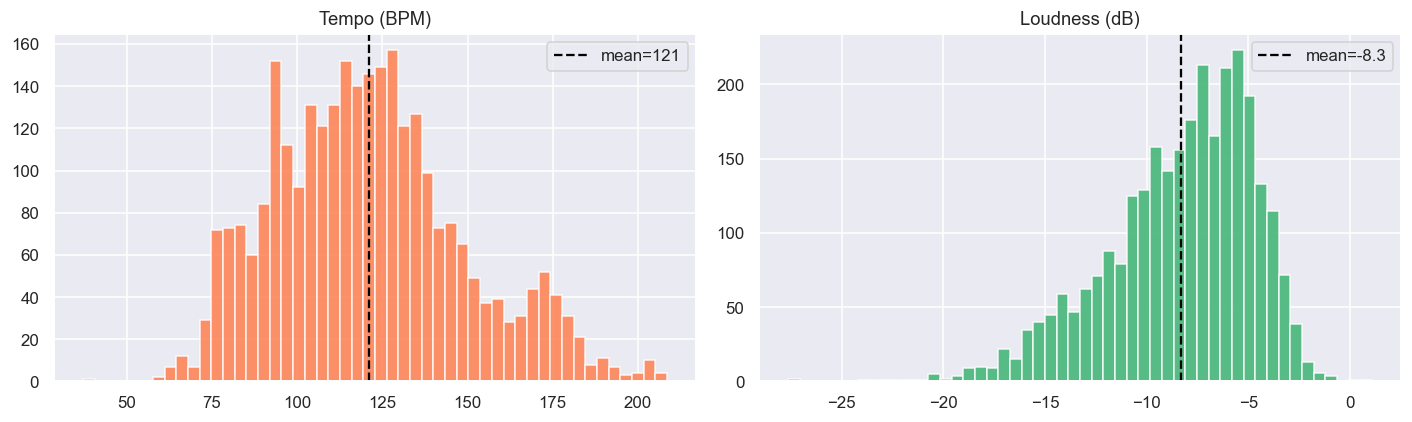

In [22]:
# ── Tempo & Loudness separately (different scales) ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df_af['tempo'], bins=50, color='coral', edgecolor='white', alpha=0.85)
axes[0].set_title('Tempo (BPM)')
axes[0].axvline(df_af['tempo'].mean(), color='black', linestyle='--',
                label=f"mean={df_af['tempo'].mean():.0f}")
axes[0].legend()

axes[1].hist(df_af['loudness'], bins=50, color='mediumseagreen', edgecolor='white', alpha=0.85)
axes[1].set_title('Loudness (dB)')
axes[1].axvline(df_af['loudness'].mean(), color='black', linestyle='--',
                label=f"mean={df_af['loudness'].mean():.1f}")
axes[1].legend()

plt.tight_layout()
plt.show()

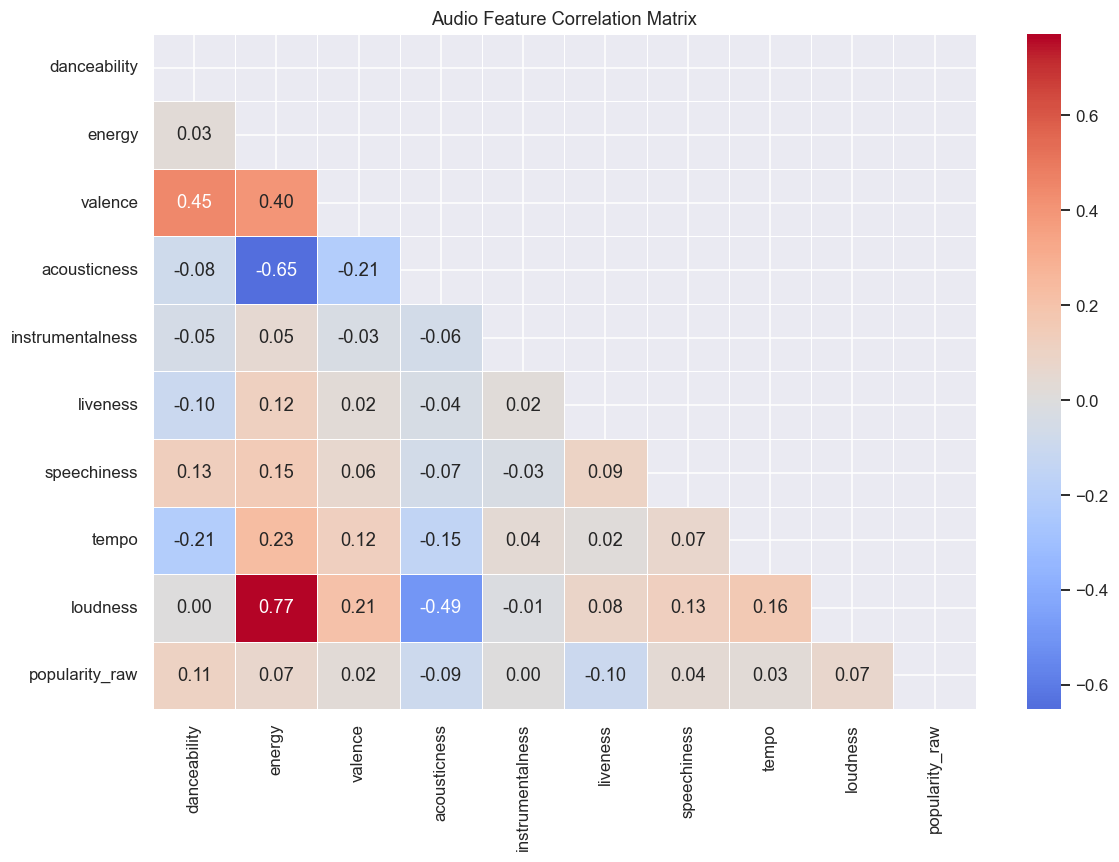

In [23]:
# ── Audio feature correlation heatmap ──────────────────────────────
corr_cols = AUDIO_FEATURES + ['tempo', 'loudness', 'popularity_raw']
corr = df_af[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Audio Feature Correlation Matrix')
plt.tight_layout()
plt.show()

Correlation matrix — key findings:

- The big one: energy ↔ loudness = 0.77. These two are measuring almost the same thing. Including both in KMeans will double-weight that dimension. I will drop loudness from clustering, keep energy (energy is more interpretable i think)
- energy ↔ acousticness = -0.65 — expected, loud electric music vs acoustic. Not redundant enough to drop but worth noting.
- danceability ↔ valence = 0.45 — moderate, both stay.
- energy ↔ valence = 0.40 — moderate, both stay.

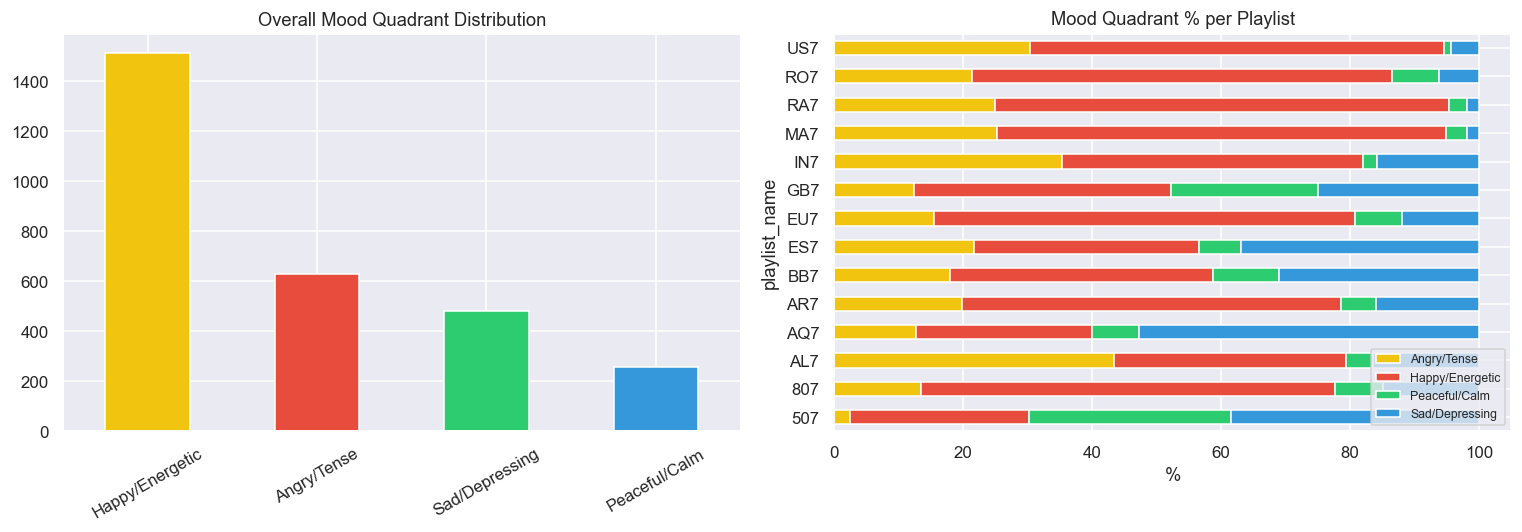

In [24]:
# ── Mood quadrant distribution ─────────────────────────────────────
mood_counts = df_af['mood_quadrant'].value_counts()
colors_mood = ['#f1c40f', '#e74c3c', '#2ecc71', '#3498db']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

mood_counts.plot(kind='bar', ax=axes[0], color=colors_mood, edgecolor='white')
axes[0].set_title('Overall Mood Quadrant Distribution')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)

# Mood per playlist (stacked bar)
mood_pl = df_af.groupby(['playlist_name', 'mood_quadrant']).size().unstack(fill_value=0)
mood_pl_pct = mood_pl.div(mood_pl.sum(axis=1), axis=0) * 100
mood_pl_pct.plot(kind='barh', stacked=True, ax=axes[1],
                 color=colors_mood, edgecolor='white')
axes[1].set_title('Mood Quadrant % per Playlist')
axes[1].set_xlabel('%')
axes[1].legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.show()

Modeling implication: GB7, 507, and AQ7 will be the easiest to classify correctly because they have distinct mood signatures. The cluster of US7/RO7/RA7/MA7 will likely confuse the model — they may need to be separated by something other than mood (tempo, decade, genre).

## 5. Audio Features per Playlist

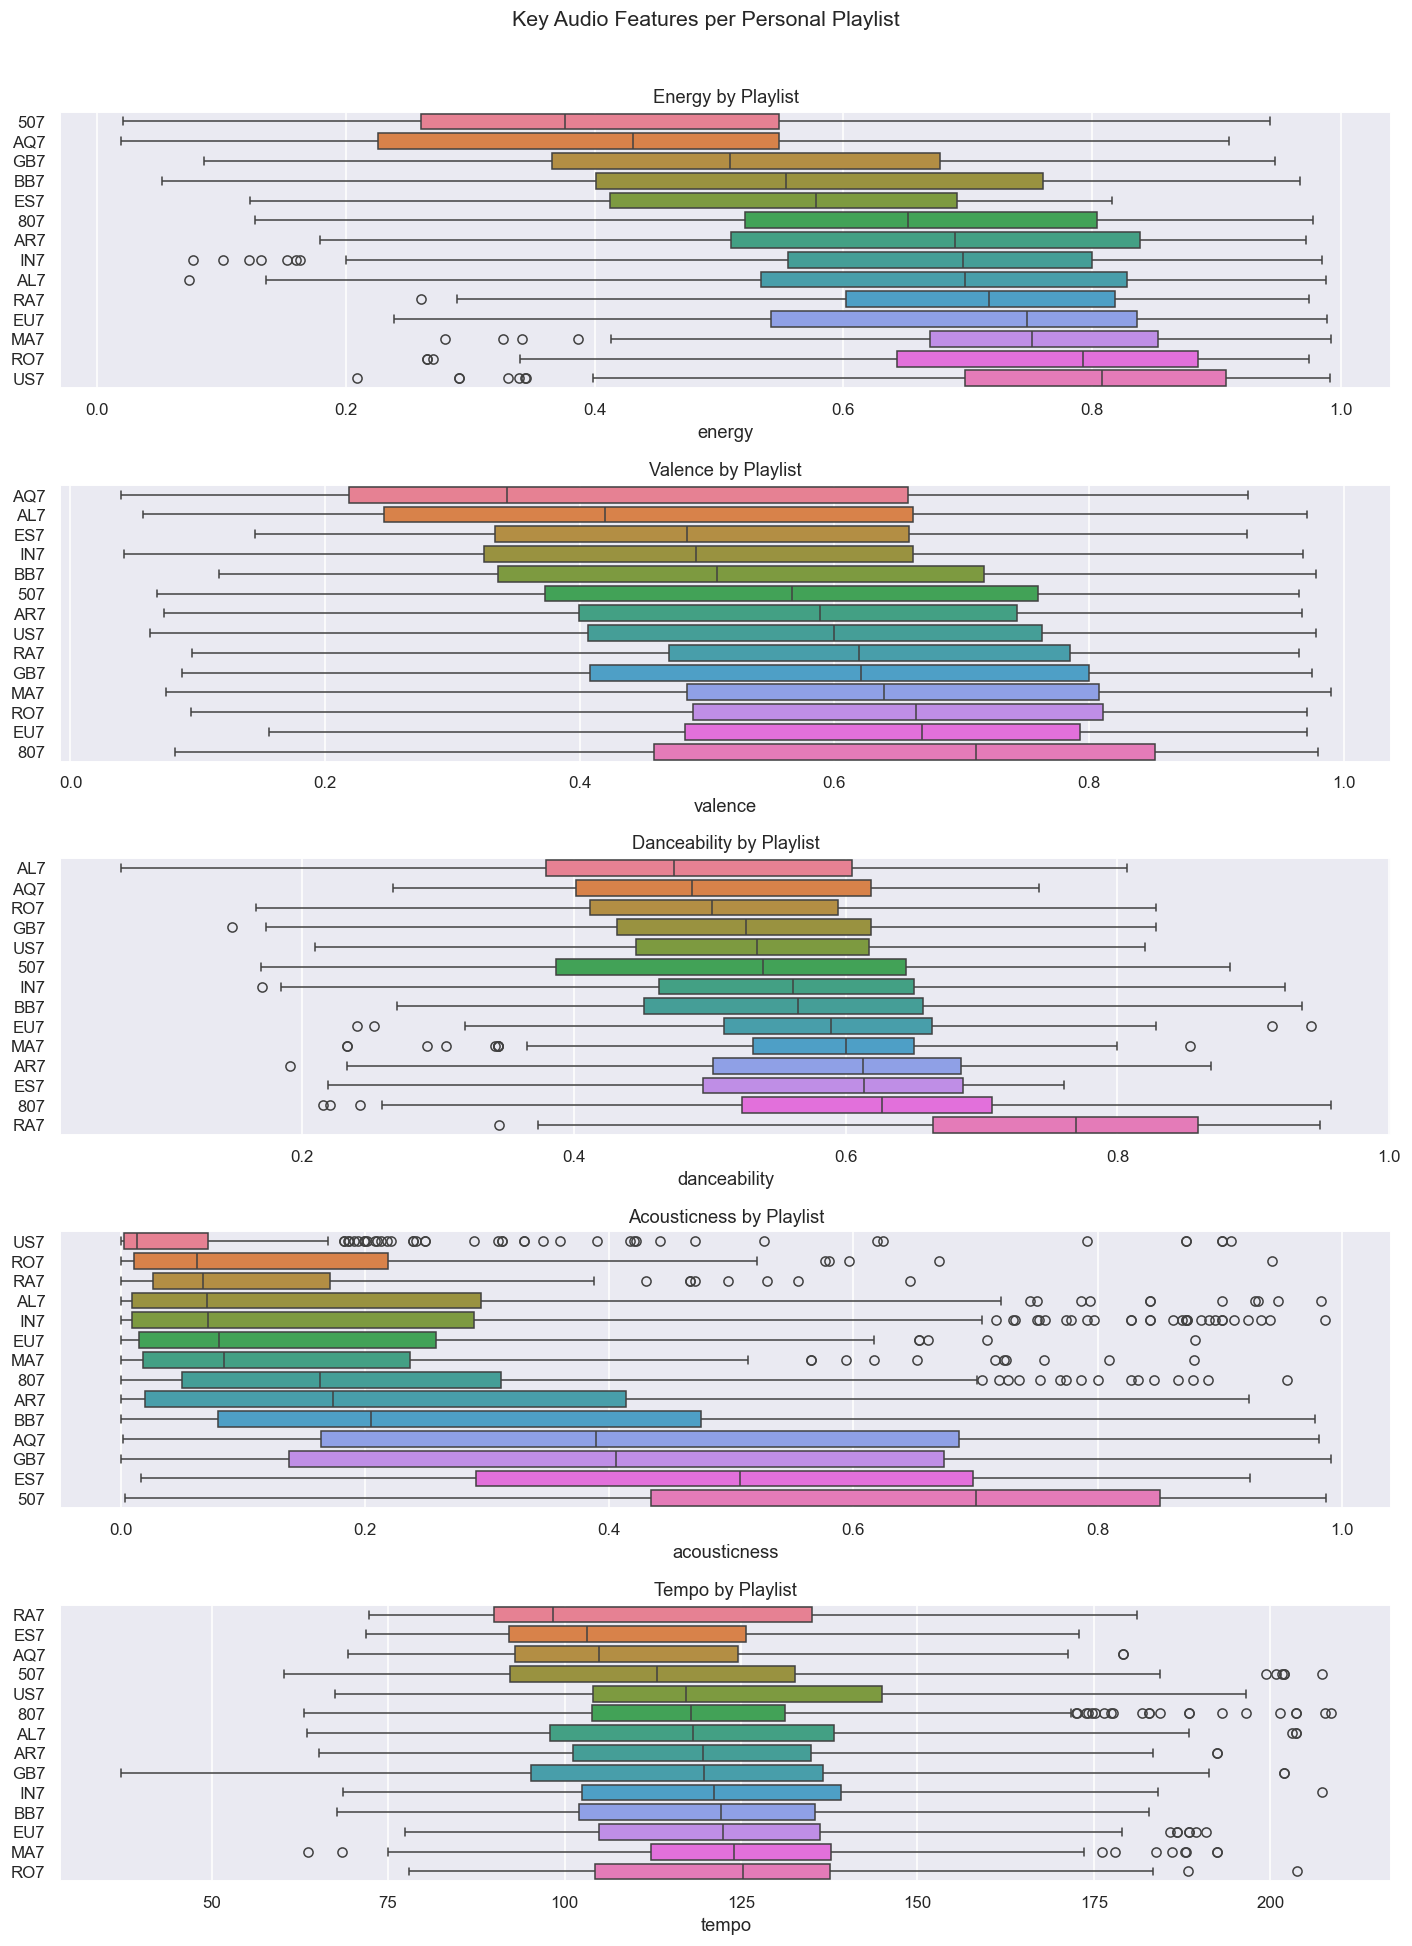

In [25]:
# ── Boxplots: key features by playlist ────────────────────────────
KEY_FEATURES = ['energy', 'valence', 'danceability', 'acousticness', 'tempo']
personal_df  = df_af[df_af['is_personal'] == True]

fig, axes = plt.subplots(len(KEY_FEATURES), 1,
                         figsize=(13, 3.5 * len(KEY_FEATURES)))

for ax, feat in zip(axes, KEY_FEATURES):
    order = personal_df.groupby('playlist_name')[feat].median().sort_values().index
    sns.boxplot(data=personal_df, x=feat, y='playlist_name',
                order=order, ax=ax, palette='husl')
    ax.set_title(f'{feat.capitalize()} by Playlist')
    ax.set_ylabel('')

plt.suptitle('Key Audio Features per Personal Playlist', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

* Energy — clearest separator. 507 and AQ7 sit noticeably lower (~0.5 median), while US7, RO7, MA7 are high (~0.75+). GB7 is mid-range. Good discriminating feature.
* Valence — wide IQRs on almost everything, heavy overlap. AQ7 is notably lower (darker mood confirmed), 807 and EU7 skew higher. But most playlists span the full range — valence alone won't separate them.
* Danceability — very little separation. Nearly all playlists cluster around 0.55–0.65. RA7 skews slightly higher. This feature will contribute minimally to both clustering and classification.
* Acousticness — the biggest separator by far. Clear split into two groups:

    * Low acousticness (electric/produced): US7, RO7, RA7, AL7, IN7, EU7, MA7 — all medians near 0

    * High acousticness (organic/acoustic): 507, ES7, GB7, AQ7, BB7, AR7 — medians 0.3–0.7

This is going to be one of the strongest features in both KMeans and the classifier.
* Tempo — moderate separation. RA7 and ES7 run faster (~125+ BPM), RO7 and MA7 slower (~100 BPM). Useful but not a clean separator.

Overall classifier outlook: Acousticness alone splits the playlists into two meaningful groups. Combined with energy for the high-acousticness group, you should get decent separation. The hard cluster remains US7/RO7/MA7/RA7 — all low acousticness, high energy, similar tempo. Genre and decade will likely be the tiebreaker there.

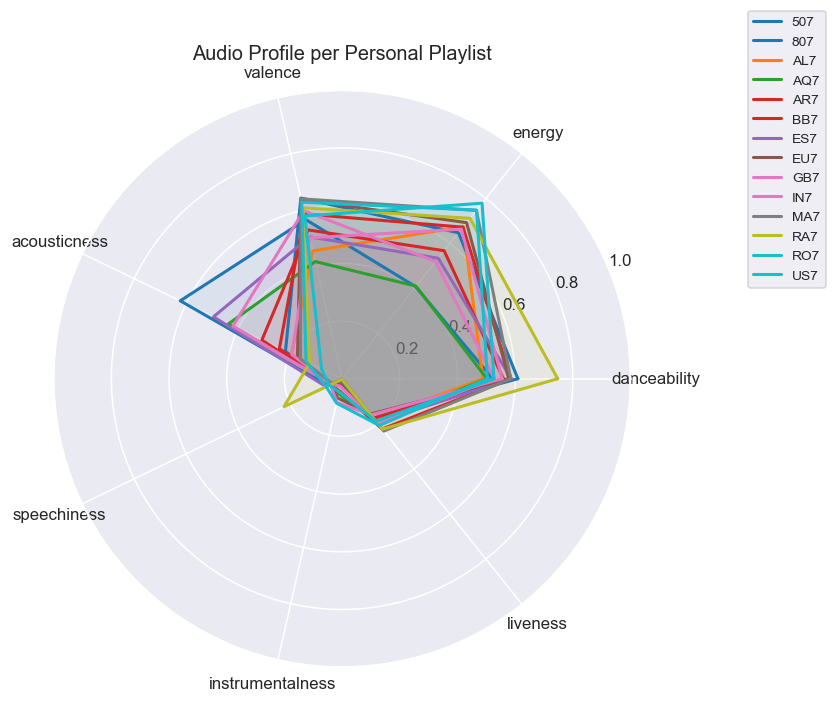

In [26]:
# ── Radar chart: mean audio profile per personal playlist ──────────
RADAR_FEATURES = ['danceability', 'energy', 'valence',
                  'acousticness', 'speechiness', 'instrumentalness', 'liveness']

pl_means = (personal_df.groupby('playlist_name')[RADAR_FEATURES]
            .mean().reset_index())

N = len(RADAR_FEATURES)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
cmap = plt.cm.get_cmap('tab10', len(pl_means))

for i, row in pl_means.iterrows():
    values = row[RADAR_FEATURES].tolist()
    values += values[:1]
    ax.plot(angles, values, color=cmap(i), linewidth=2, label=row['playlist_name'])
    ax.fill(angles, values, color=cmap(i), alpha=0.07)

ax.set_thetagrids(np.degrees(angles[:-1]), RADAR_FEATURES)
ax.set_ylim(0, 1)
ax.set_title('Audio Profile per Personal Playlist', pad=20, fontsize=13)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)
plt.tight_layout()
plt.show()

The radar confirms everything the boxplots told us, but now you can see the full fingerprints clearly.
The two standout playlists:

- 507 (dark blue) — massive acousticness spike, pulls way out to the left. Completely distinct shape from everyone else. Will be the easiest to classify correctly.
- RA7 (yellow-green) — huge danceability spike, stands out on the right. Also very identifiable.

## 6. Popularity & Duration

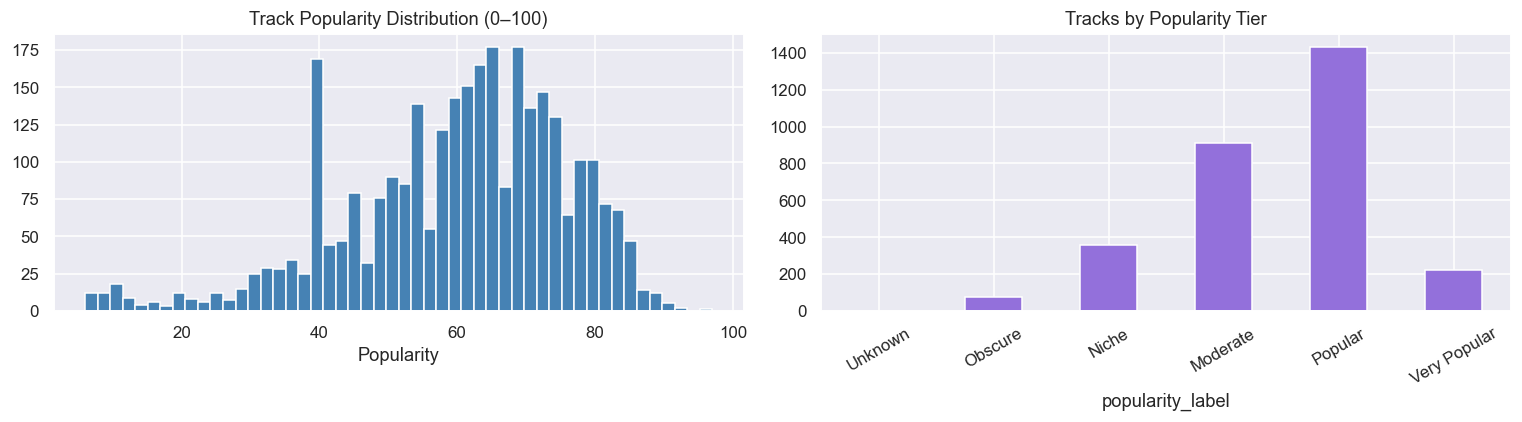

Popularity stats:
count   2998.0000
mean      59.9513
std       16.1196
min        6.0000
25%       50.0000
50%       63.0000
75%       72.0000
max       97.0000
Name: popularity_raw, dtype: float64


In [27]:
# ── Popularity distribution ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df['popularity_raw'].hist(bins=50, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Track Popularity Distribution (0–100)')
axes[0].set_xlabel('Popularity')

pop_order = ['Unknown', 'Obscure', 'Niche', 'Moderate', 'Popular', 'Very Popular']
pop_counts = df['popularity_label'].value_counts().reindex(pop_order)
pop_counts.plot(kind='bar', ax=axes[1], color='mediumpurple', edgecolor='white')
axes[1].set_title('Tracks by Popularity Tier')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print('Popularity stats:')
print(df['popularity_raw'].describe())

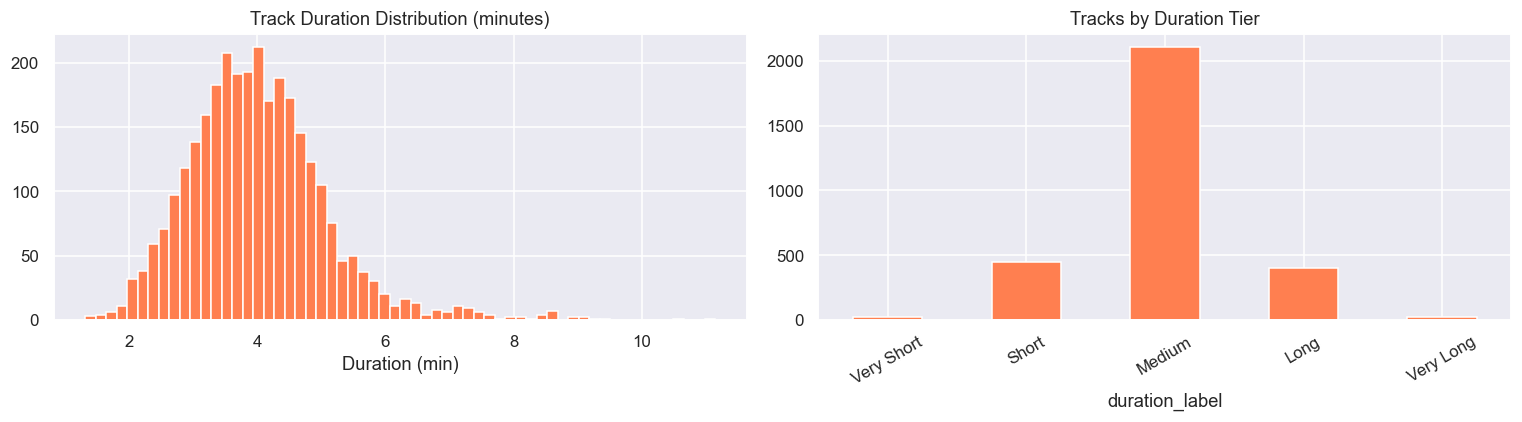

In [28]:
# ── Duration ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df['duration_raw'].hist(bins=60, ax=axes[0], color='coral', edgecolor='white')
axes[0].set_title('Track Duration Distribution (minutes)')
axes[0].set_xlabel('Duration (min)')

dur_order = ['Very Short', 'Short', 'Medium', 'Long', 'Very Long']
dur_counts = df['duration_label'].value_counts().reindex(dur_order)
dur_counts.plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Tracks by Duration Tier')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 7. Temporal Analysis

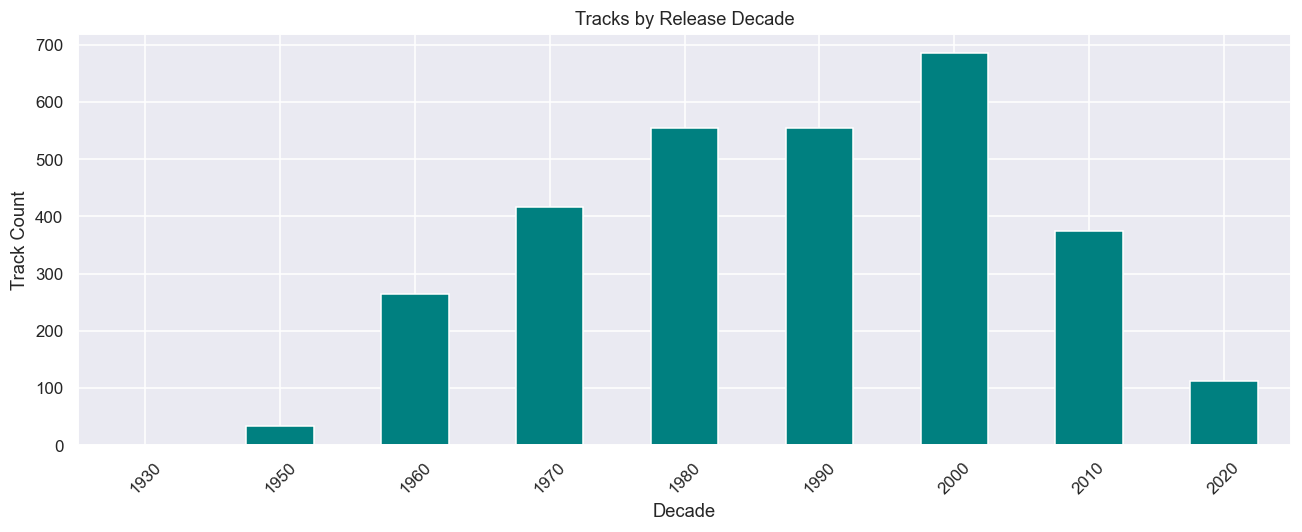

In [35]:
# ── Release decade distribution ────────────────────────────────────
decade_counts = df.dropna(subset=['decade']).groupby('decade')['fact_id'].count()

decade_counts.plot(kind='bar', color='teal', edgecolor='white',
                   title='Tracks by Release Decade')
plt.xlabel('Decade')
plt.ylabel('Track Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

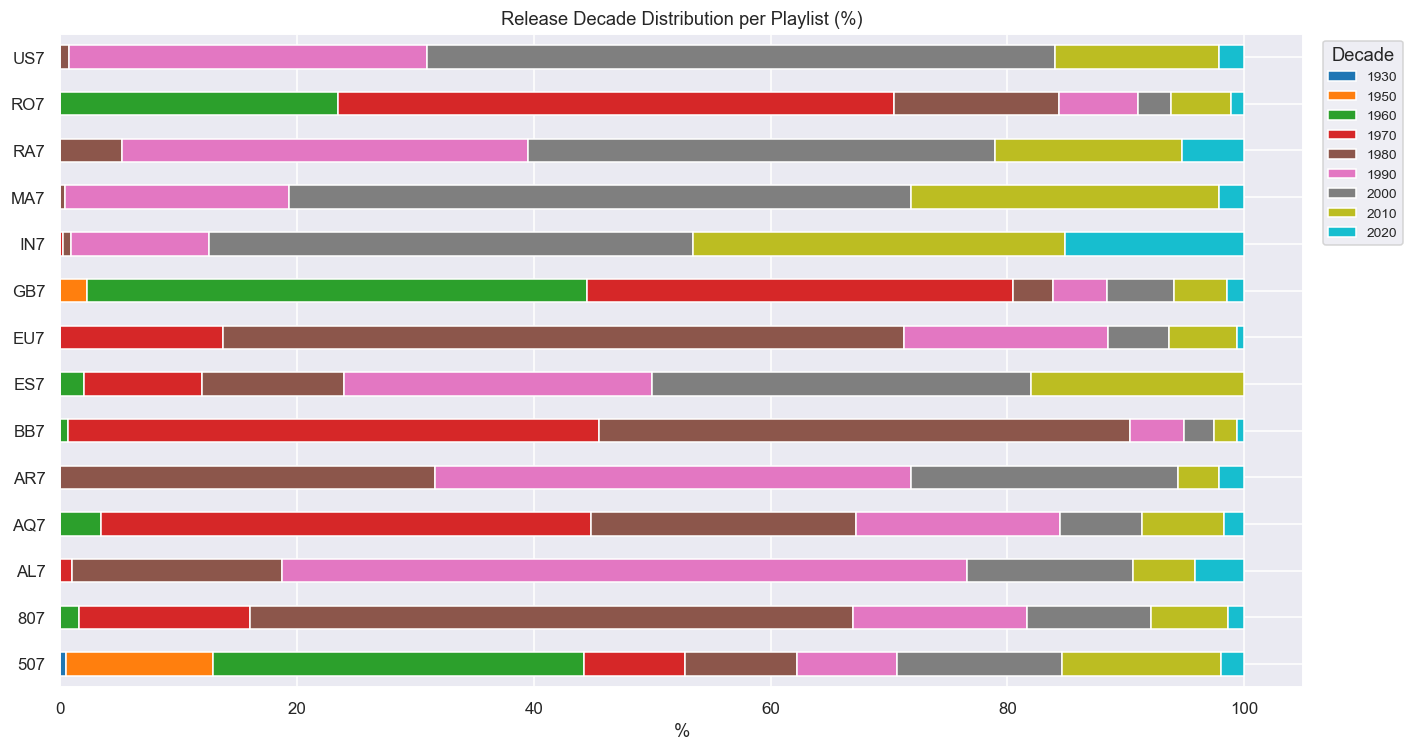

decade         1930  1950  1960  1970  1980  1990  2000  2010  2020
playlist_name                                                      
507               1    25    63    17    19    17    28    27     4
807               0     0     7    62   219    63    45    28     6
AL7               0     0     0     2    34   111    27    10     8
AQ7               0     0     2    24    13    10     4     4     1
AR7               0     0     0     0    45    57    32     5     3
BB7               0     0     1    70    70     7     4     3     1
ES7               0     0     1     5     6    13    16     9     0
EU7               0     0     0    24   100    30     9    10     1
GB7               0     8   149   127    12    16    20    16     5
IN7               0     0     0     1     3    50   176   135    65
MA7               0     0     0     0     1    45   125    62     5
RA7               0     0     0     0     6    39    45    18     6
RO7               0     0    42    84    25    1

In [36]:
# ── Decade breakdown per playlist ─────────────────────────────────
decade_pl = (df.dropna(subset=['decade'])
               .groupby(['playlist_name', 'decade'])
               .size()
               .unstack(fill_value=0))

# Normalize to % within each playlist
decade_pl_pct = decade_pl.div(decade_pl.sum(axis=1), axis=0) * 100

decade_pl_pct.plot(
    kind='barh', stacked=True, figsize=(13, 7),
    colormap='tab10', edgecolor='white'
)
plt.title('Release Decade Distribution per Playlist (%)')
plt.xlabel('%')
plt.ylabel('')
plt.legend(title='Decade', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

# Absolute counts table
print(decade_pl.to_string())

Clear patterns:

- GB7 — heavily 1960s–70s (green + red dominates). Completely unique era profile, the most vintage playlist by far. Combined with its high acousticness, this will be trivially easy to classify.
- BB7 — almost entirely 1970s–80s (red + brown). Very distinctive.
- RO7 — 1960s heavy (~25%) then spread across decades. Another vintage-leaning playlist.
- 507 — spans everything from 1950s to 2020s fairly evenly. The most temporally diverse playlist.
- IN7, MA7, US7 — dominated by 2000s–2010s (grey + yellow-green). Modern playlists.
- RA7 — 1990s heavy (pink ~40%) then 2000s. The most 90s-concentrated playlist.
- AR7, AL7, 807 — balanced across 1980s–2000s, the hardest to separate by decade alone.

## 8. Artist & Genre Analysis

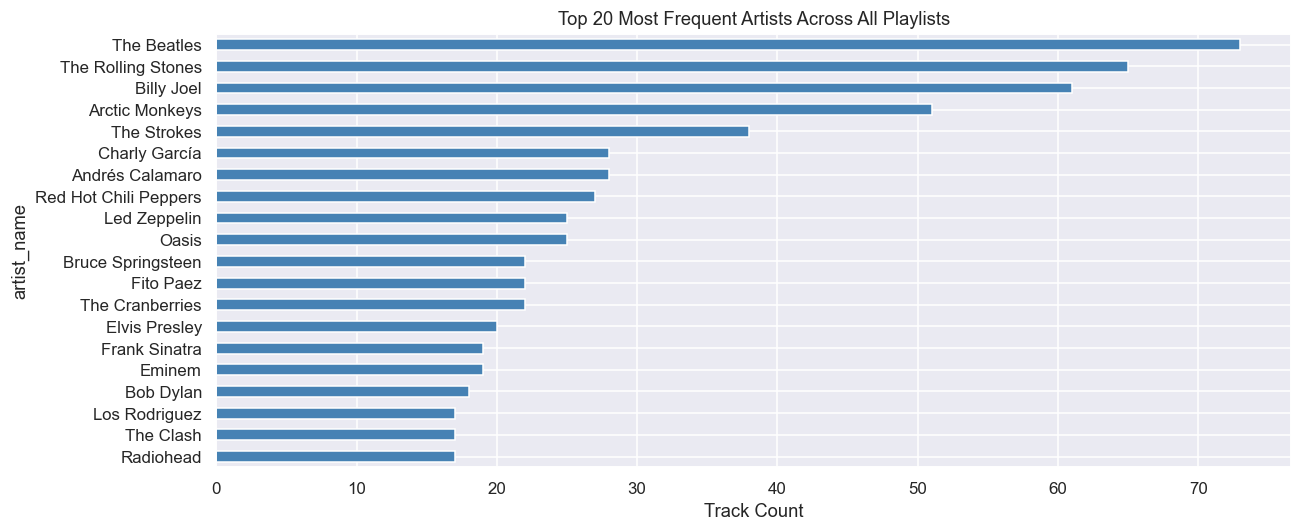

In [31]:
# ── Top artists ────────────────────────────────────────────────────
top_artists = df.groupby('artist_name')['fact_id'].count().sort_values(ascending=False).head(20)

top_artists.sort_values().plot(
    kind='barh', color='steelblue', edgecolor='white',
    title='Top 20 Most Frequent Artists Across All Playlists'
)
plt.xlabel('Track Count')
plt.tight_layout()
plt.show()

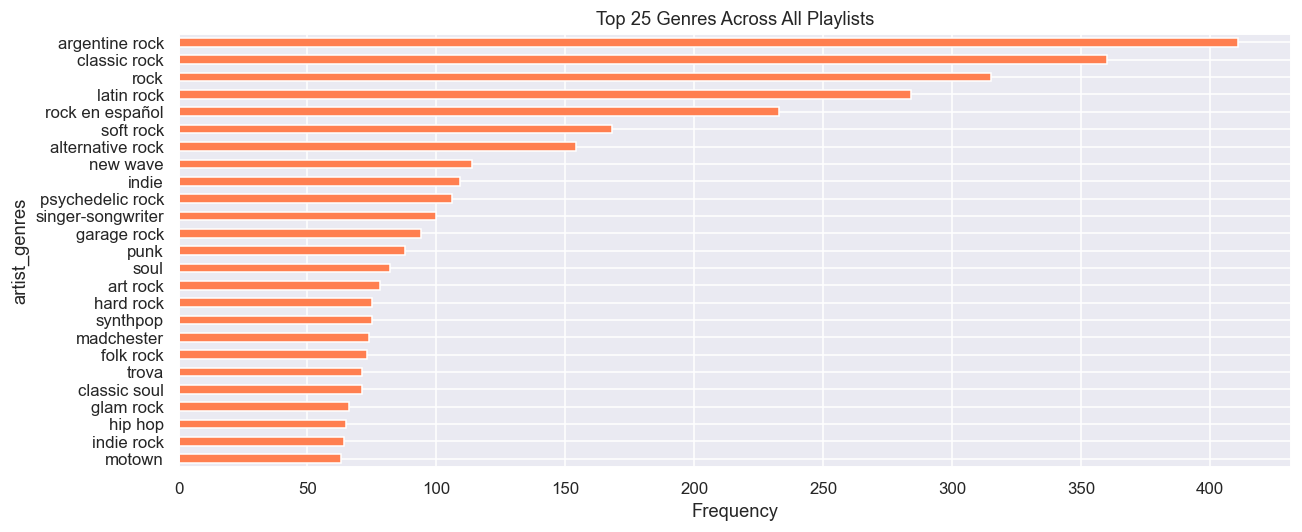

Total unique genres: 209


In [37]:
# ── Genre extraction & frequency ──────────────────────────────────
all_genres = (df['artist_genres']
              .dropna()
              .str.split(',')
              .explode()
              .str.strip()
              .str.lower()
              .replace('', pd.NA)
              .dropna())

top_genres = all_genres.value_counts().head(25)

top_genres.sort_values().plot(
    kind='barh', color='coral', edgecolor='white',
    title='Top 25 Genres Across All Playlists'
)
plt.xlabel('Frequency')
plt.tight_layout()
plt.show()

print(f'Total unique genres: {all_genres.nunique()}')

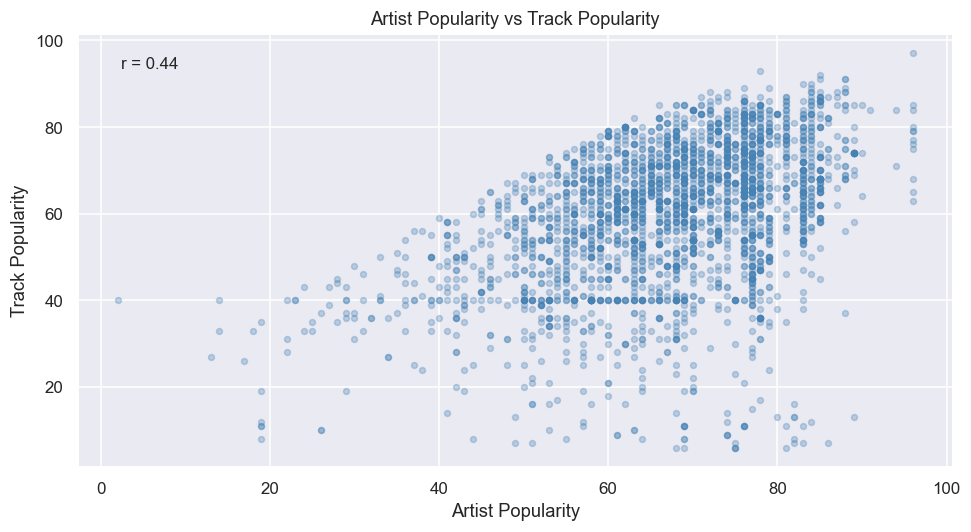

In [38]:
# ── Artist popularity vs track popularity ─────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(df['artist_popularity'], df['popularity_raw'],
           alpha=0.3, s=15, color='steelblue')
ax.set_xlabel('Artist Popularity')
ax.set_ylabel('Track Popularity')
ax.set_title('Artist Popularity vs Track Popularity')
corr_val = df[['artist_popularity','popularity_raw']].corr().iloc[0,1]
ax.text(0.05, 0.92, f'r = {corr_val:.2f}', transform=ax.transAxes, fontsize=11)
plt.tight_layout()
plt.show()

## 9. Key Takeaways & Modeling Ideas


### Observations

**Coverage**
- 96.2% of tracks enriched by reccobeats — effectively a clean dataset
- All playlists meet the coverage threshold — no exclusions needed
- Remaining ~4% nulls are likely local tracks or unmatched records; safe to drop before modeling

**Distributions**
- Skewed features: `instrumentalness` (mean=0.04), `speechiness` (mean=0.05) — zero-spike with long tail → log-transform or exclude from KMeans (we are log-transforming `speechiness` as it helps distinguishing between high-energy rock and high-energy rap)
- `liveness` (mean=0.19) is borderline skewed — exclude from KMeans, keep for classifier
- `track_number` and `time_signature` are ~100% null → dropped entirely
- `danceability`, `energy`, `valence`, `tempo`, `loudness` are well-distributed and suitable for KMeans as-is
- `energy` ↔ `loudness` correlation = 0.77 → drop `loudness` from KMeans (redundant), keep for classifier
- `popularity_raw` uncorrelated with all audio features (max r=0.11) → independent signal for classifier only

**Playlist separation**
- Playlists are separable but not uniformly — `acousticness` and `decade` are the strongest separators
- `GB7`: uniquely high acousticness + 1960s–70s era → easiest to classify
- `BB7`: 1970s–80s heavy, high acousticness → very identifiable
- `507`: highest acousticness overall, most temporally diverse → distinct profile
- `RA7`: highest danceability, 1990s-concentrated → identifiable
- `AQ7`: lowest energy + valence (darkest mood) → distinct
- Hardest cases: `US7`, `RO7`, `MA7`, `IN7` — all low acousticness, high energy, modern era, similar mood profiles → will likely require genre features to separate

**Ideas that emerged**
- Era-based audio analysis: audio features shift meaningfully across decades — worth a dedicated visualization in the Streamlit app
- Vintage vs. modern split: acousticness + decade naturally partition playlists into two macro-groups; could be a useful pre-filter before classification
- Outlier detection: songs far from their playlist's centroid are candidates for "wrong playlist" — interesting app feature